In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit, minimize

from readrbdata import load

import matplotlib.pyplot as plt

from fittingutils import *
from readrbdata import transform

%matplotlib widget

In [2]:
spike_data = []

In [3]:
sat = load(sat=True, mag=False)
uns = load(sat=False, mag=False)

# this makes the two signals agree a lot more, very annoyingly...
def loss(offset):
    diff = sat.signal - np.interp(sat.frequency + offset, uns.frequency, uns.signal, left=np.nan, right=np.nan)
    diff = diff[np.isfinite(diff)]
    return np.sum(diff**2)

offset_opt_res = minimize(loss, 0.)
offset_opt_res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 47081.7751735552
        x: [-1.905e-02]
      nit: 8
      jac: [ 0.000e+00]
 hess_inv: [[ 1.057e-10]]
     nfev: 28
     njev: 14

In [4]:
# whatever
sat.frequency += offset_opt_res.x[0]

In [5]:
diff_freq = sat.frequency

diff_signal = sat.signal - np.interp(diff_freq, uns.frequency, uns.signal, left=np.nan, right=np.nan)

ok_idx = np.isfinite(diff_signal)

diff_signal = diff_signal[ok_idx]
diff_freq = diff_freq[ok_idx]

In [6]:
sat.frequency[0], uns.frequency[0]

(-0.23227264125477856, -0.27870648334215753)

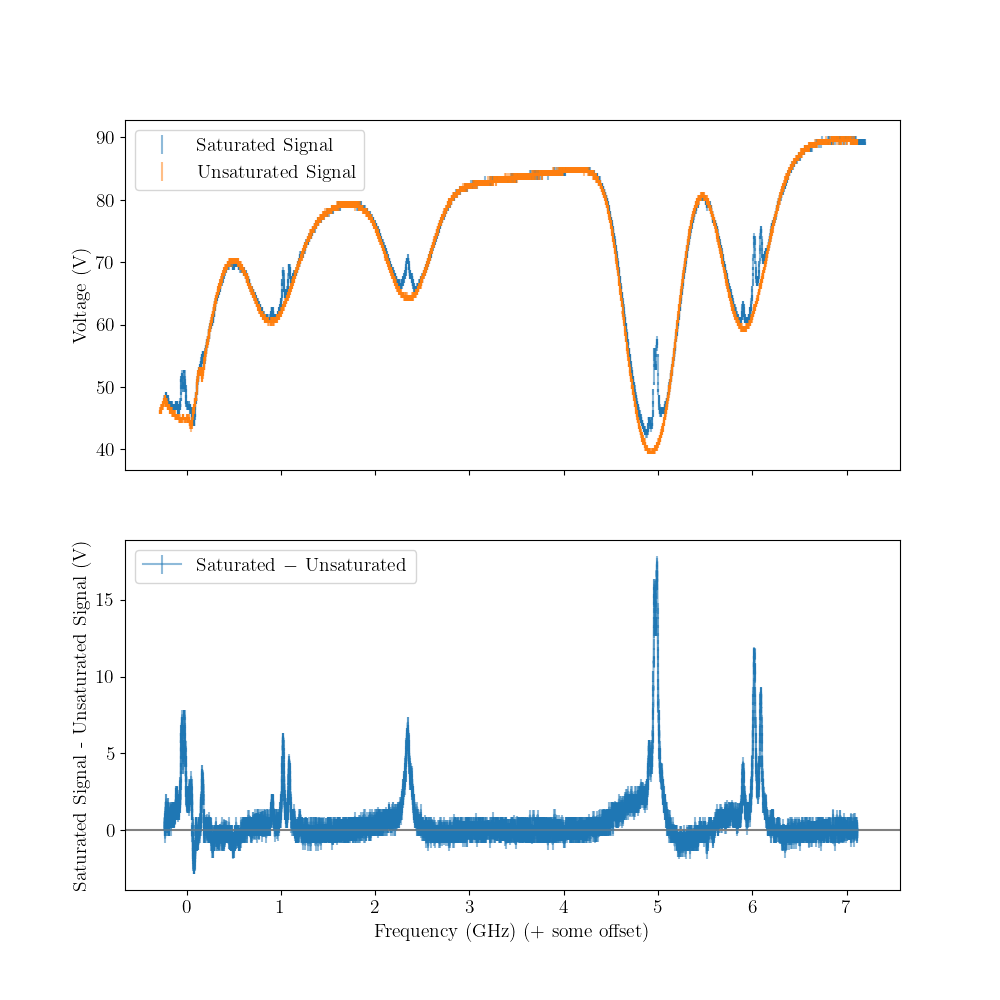

In [7]:
fig, (sig_ax, diff_ax) = plt.subplots(nrows=2, sharex=True, figsize=(10, 10))

sig_ax.errorbar(sat.frequency, sat.signal, yerr=0.25, alpha=0.5, label='Saturated Signal', ls='')
sig_ax.errorbar(uns.frequency, uns.signal, yerr=0.25, alpha=0.5, label='Unsaturated Signal', ls='')
sig_ax.set_ylabel('Voltage (V)')
sig_ax.legend()

diff_ax.errorbar(diff_freq, diff_signal, yerr=np.sqrt(2)*0.25, alpha=0.5, label='Saturated $-$ Unsaturated')
diff_ax.axhline(0., color="gray")
diff_ax.set_xlabel('Frequency (GHz) (+ some offset)')
diff_ax.set_ylabel('Saturated Signal - Unsaturated Signal (V)')
diff_ax.legend()

# Fit Ugly One

Fitting this one all at once just because they're so close together

In [8]:
def triple_lorentzian(
        x, 
        x00, g0, a0, 
        x01, g1, a1, 
        x02, g2, a2, 
        offset, offset_slope
):
    return Lorentzian(x, x00, g0, a0, 0.) + Lorentzian(x, x01, g1, a1, 0.) + Lorentzian(x, x02, g2, a2, 0.) + offset + x*offset_slope

len(p0) = 11
fit params:
[ 4.90660883e+00  9.57686317e-03  2.93349754e+00  4.96096085e+00
  1.14178156e-02  1.10103154e+01  4.98860413e+00  1.49472479e-02
  1.36454202e+01  1.91435624e+01 -3.55651921e+00]
cov:
[[ 1.64235889e-07  4.72580650e-09 -5.14919882e-07 -4.22988813e-10
  -1.34118980e-08 -2.14103460e-07 -3.07644692e-09  2.19092645e-09
   3.08615280e-06  3.08447027e-05 -6.10715297e-06]
 [ 4.72580650e-09  4.47426964e-07 -4.75049204e-05 -2.84737445e-09
  -3.97524541e-08 -8.45812933e-07 -8.96633170e-09  1.65925591e-08
   1.31138347e-05 -1.64558600e-04  3.16821811e-05]
 [-5.14919882e-07 -4.75049204e-05  1.52025151e-02 -5.25474844e-07
   2.45091231e-07  5.88605784e-04  6.88678194e-08  4.70588348e-07
   3.76650613e-04 -3.22746913e-03  5.84965153e-04]
 [-4.22988813e-10 -2.84737445e-09 -5.25474844e-07  2.61177343e-08
   2.14370780e-08  7.88424004e-06  1.59834692e-08 -2.08567004e-08
  -8.71639510e-06 -2.05841605e-05  4.33058974e-06]
 [-1.34118980e-08 -3.97524541e-08  2.45091231e-07  2.14370

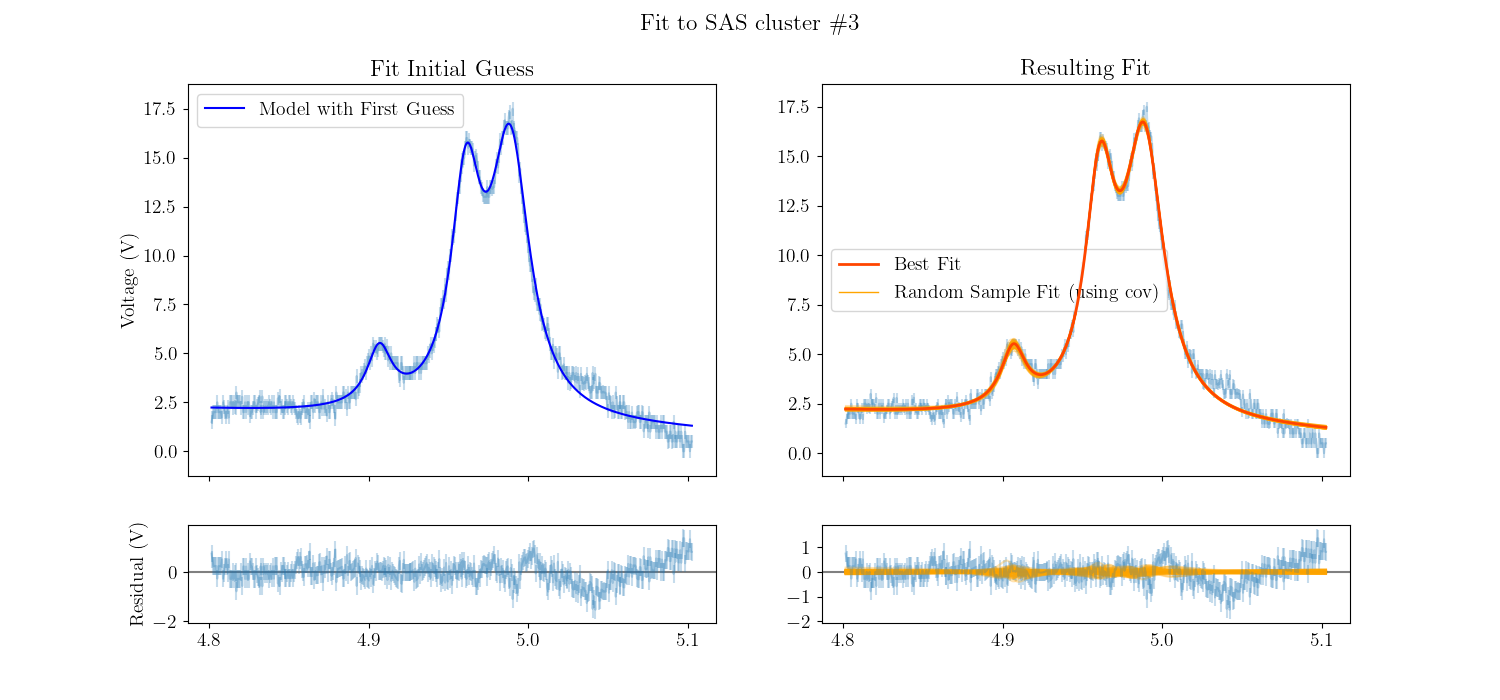

In [9]:
x_low = .034 # remnant from when i worked in time units i am too lazy to fix
x_high = .038
cluster_n = 2

# MAKE PLOTS
fig, ((guess_data_ax, fit_data_ax), (guess_res_ax, fit_res_ax)) = plt.subplots(2, 2, sharex=True, height_ratios=[4, 1], figsize=(15, 7))

# ESTABLISH INITIAL GUESSES
spidx, = np.nonzero((x_low <= sat.time) & (sat.time < x_high)) # single peak indices

x = diff_freq[spidx]
y = diff_signal[spidx]

baseline_slope_guess = (y[-1] - y[0]) / (x[-1] - x[0])

# p0 = [
#     4.92546154e+00,
#     9.86185753e-03,  
#     3.04749742e+00,  
    
#     4.97997906e+00,
#     1.10517537e-02,
#     1.12703114e+01,
    
#     5.00778981e+00,
#     1.48773556e-02,
#     1.39587998e+01,
    
#     7.11786513e+01,
#     -1.40941661e+01
# ]

p0 = [
    4.90660884e+00,
    9.57678660e-03,
    2.93350539e+00,
    
    4.96096085e+00,
    1.14178255e-02,
    1.10103184e+01,
    
    4.98860413e+00,
    1.49472351e-02,
    1.36454183e+01,
    
    1.91435783e+01,
    -3.55652205e+00
]
print(f"{len(p0) = }")

guess_data_ax.errorbar(x, y, yerr=np.sqrt(2)*0.25, alpha=0.25)
guess_data_ax.plot(x, triple_lorentzian(x, *p0), zorder=10, color='blue', label='Model with First Guess')

guess_data_ax.set_title('Fit Initial Guess')
guess_data_ax.set_ylabel('Voltage (V)')
guess_data_ax.legend()

residuals = triple_lorentzian(x, *p0) - y

guess_res_ax.axhline(0., color='gray')
guess_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
guess_res_ax.set_ylabel('Residual (V)')
# guess_res_ax.set_ylim(np.min(residuals), np.max(residuals))

fit_params, cov = curve_fit(triple_lorentzian, x, y, p0, np.sqrt(2)*0.25)
print(f"fit params:\n{fit_params}")
print(f"cov:\n{cov}")

fit_data_ax.errorbar(x, y, yerr=0.25, alpha=0.25)
fit_data_ax.plot(x, triple_lorentzian(x, *fit_params), lw=2, c='orangered', zorder=10, label='Best Fit')
data_y_lims = fit_data_ax.set_ylim()

random_fit_samples = np.random.multivariate_normal(fit_params, cov, 64)
for fit_sample in random_fit_samples:
    fit_data_ax.plot(x, triple_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, alpha=0.3)
fit_data_ax.plot(x, triple_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, label='Random Sample Fit (using cov)')

fit_data_ax.legend()

fit_data_ax.set_ylim(data_y_lims)
fit_data_ax.set_title('Resulting Fit')

residuals = triple_lorentzian(x, *fit_params) - y

fit_res_ax.axhline(0., color='gray')
fit_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
for fit_sample in random_fit_samples:
    fit_res_ax.plot(x, triple_lorentzian(x, *fit_sample) - triple_lorentzian(x, *fit_params), c='orange', alpha=0.3)

fig.suptitle(f'Fit to SAS cluster \\#{cluster_n + 1}')

for i in range(3):
    this_spike = {
        "center_freq": fit_params[0 + i*3],
        "e_center_freq": np.sqrt(np.diag(cov))[0 + i*3],
        "amplitude": fit_params[2 + i*3],
        "cluster_id": cluster_n
    }

    print(f"{this_spike = }")

    if this_spike not in spike_data:
        spike_data.append(this_spike)
    else:
        print('SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE')

    print(f"{len(spike_data) = }")


plt.locator_params(nbins=5)

In [10]:
def red_lorentzian(x, center, gamma, amplitude, baseline, baseline_slope):
    return Lorentzian(x, center, gamma, amplitude, baseline) + baseline_slope*x

In [11]:
def fit_spike(x_low, x_high, cluster_n):
    # MAKE PLOTS
    fig, ((guess_data_ax, fit_data_ax), (guess_res_ax, fit_res_ax)) = plt.subplots(2, 2, sharex=True, height_ratios=[4, 1], figsize=(15, 7))

    # ESTABLISH INITIAL GUESSES
    spidx, = np.nonzero((x_low <= sat.time) & (sat.time < x_high)) # single peak indices

    x = diff_freq[spidx]
    y = diff_signal[spidx]

    center_guess = x[np.argmax(diff_signal[spidx])]
    slope_guess = (y[-1] - y[0]) / (x[-1] - x[0])

    p0 = [
        center_guess,
        Lorentzian.guess_gamma(x, y),
        np.max(y) - (slope_guess*(center_guess - x[0]) + y[0]),
        y[0] - slope_guess*x[0],
        slope_guess
    ]
    print(f"{p0 = }")

    guess_data_ax.errorbar(x, y, yerr=np.sqrt(2)*0.25, alpha=0.25)
    guess_data_ax.plot(x, red_lorentzian(x, *p0), zorder=10, color='blue')

    # guess_data_ax.axvline(p0[0], label='x0 guess', c='red', alpha=0.5)
    # guess_data_ax.plot([p0[0] - p0[1], p0[0] + p0[1]], [(p0[2] + p0[3] + slope_guess*x[0])/2, (p0[2] + p0[3] + slope_guess*x[0])/2], color='green', alpha=0.5, label='FWHM guess')
    # # guess_data_ax.axhline(p0[2] + p0[3] + slope_guess*x[0], label='amplitude guess', c='red', alpha=0.5)
    # guess_data_ax.axline(slope_guess*(center_guess - x[0]) + y[0], slope=slope_guess)
    # guess_data_ax.axhline(p0[3] + slope_guess*x[0], label='baseline guess', c='red', alpha=0.5)

    guess_data_ax.set_title('Fit Initial Guess')
    guess_data_ax.set_ylabel('Voltage (V)')
    guess_data_ax.legend()

    residuals = red_lorentzian(x, *p0) - y

    guess_res_ax.axhline(0., color='gray')
    guess_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
    guess_res_ax.set_ylabel('Residual (V)')
    # guess_res_ax.set_ylim(np.min(residuals), np.max(residuals))
    
    fit_params, cov = curve_fit(red_lorentzian, x, y, p0, np.sqrt(2)*0.25)
    print(f"fit params:\n{fit_params}")
    print(f"cov:\n{cov}")

    fit_data_ax.errorbar(x, y, yerr=0.25, alpha=0.25)
    fit_data_ax.plot(x, red_lorentzian(x, *fit_params), lw=2, c='orangered', zorder=10, label='Best Fit')
    data_y_lims = fit_data_ax.set_ylim()

    random_fit_samples = np.random.multivariate_normal(fit_params, cov, 64)
    for fit_sample in random_fit_samples:
        fit_data_ax.plot(x, red_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5)
    fit_data_ax.plot(x, red_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, label='Covariance Sample')
    
    fit_data_ax.legend()

    fit_data_ax.set_ylim(data_y_lims)
    fit_data_ax.set_title('Resulting Fit')

    residuals = red_lorentzian(x, *fit_params) - y

    fit_res_ax.axhline(0., color='gray')
    fit_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
    for fit_sample in random_fit_samples:
        fit_res_ax.plot(x, red_lorentzian(x, *fit_sample) - red_lorentzian(x, *fit_params), c='orange')

    fig.suptitle(f'Fit to SAS cluster \\#{cluster_n + 1}')
    np.sqrt(np.diag(cov))
    this_spike = {
        "center_freq": fit_params[0],
        "e_center_freq": np.sqrt(np.diag(cov))[0],
        "amplitude": fit_params[2],
        "cluster_id": cluster_n
    }

    print(f"{this_spike = }")

    if this_spike not in spike_data:
        spike_data.append(this_spike)
    else:
        print('SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE')

    print(f"{len(spike_data) = }")
    plt.locator_params(nbins=5)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [0.9031872574972754, 0.005264389329827868, 1.5962614962188153, 1.231270519787469, -0.9162352647659897]
fit params:
[ 0.90861177  0.01045167  1.67248114  0.25472306 -0.0023814 ]
cov:
[[ 2.08560835e-07  3.20006414e-09  1.15395833e-07  5.00505299e-05
  -5.53100618e-05]
 [ 3.20006414e-09  7.18113129e-07 -2.48247700e-05 -4.06151436e-06
  -1.53697920e-05]
 [ 1.15395833e-07 -2.48247700e-05  5.22360898e-03  1.44556546e-04
  -6.00894215e-04]
 [ 5.00505299e-05 -4.06151436e-06  1.44556546e-04  2.19975231e-01
  -2.42042762e-01]
 [-5.53100618e-05 -1.53697920e-05 -6.00894215e-04 -2.42042762e-01
   2.67564511e-01]]
this_spike = {'center_freq': 0.9086117735684698, 'e_center_freq': 0.0004566846124732839, 'amplitude': 1.6724811383895228, 'cluster_id': 0}
len(spike_data) = 4


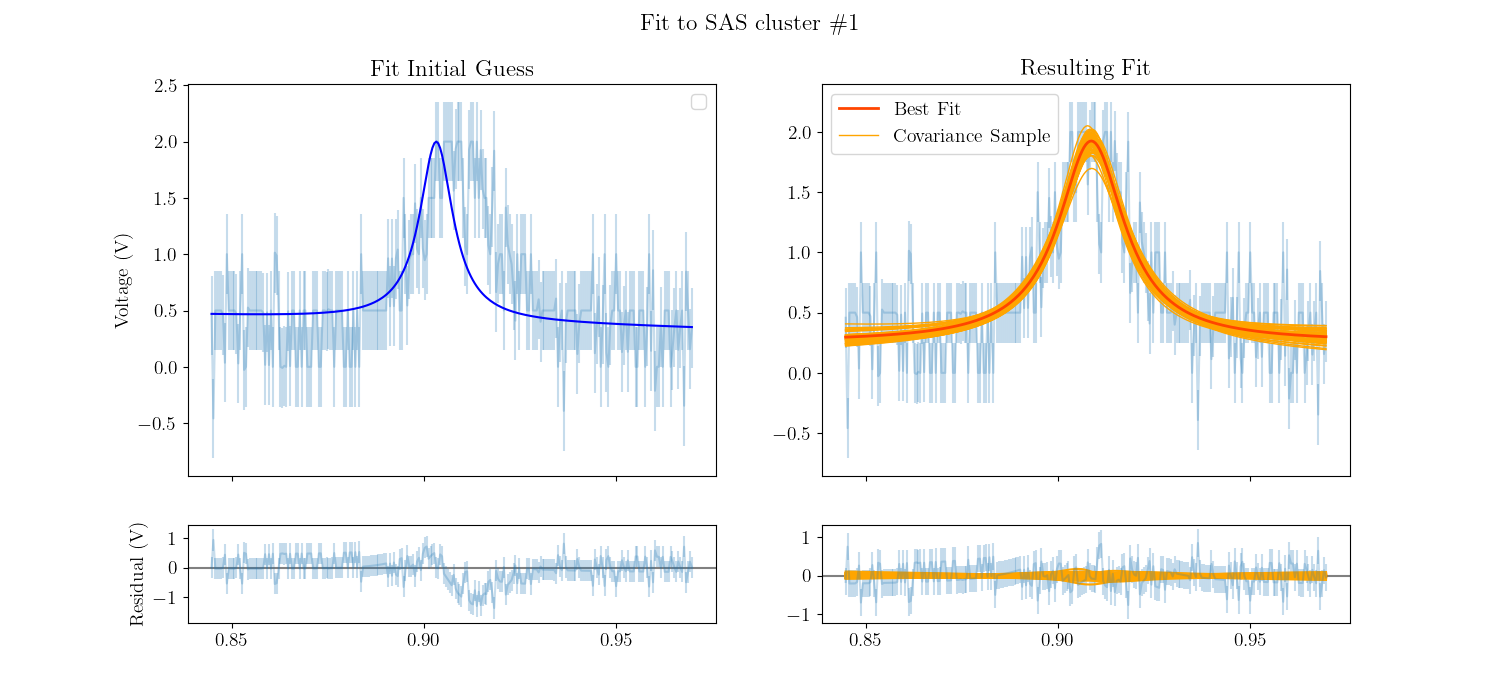

In [12]:
fit_spike(-.022, -.02, 0)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [1.0223442548639226, 0.010427241960593081, 5.14004782622978, -3.09716413590953, 3.870629967208507]
fit params:
[ 1.02382413  0.01143382  5.70555537 -0.54410071  0.7371737 ]
cov:
[[ 1.71421223e-08  5.79363975e-09  1.13379517e-06  5.01256979e-05
  -5.05120999e-05]
 [ 5.79363975e-09  8.43534781e-08  2.48921662e-07  9.89008747e-05
  -1.08872141e-04]
 [ 1.13379517e-06  2.48921662e-07  4.70201585e-03  2.02453488e-02
  -2.15487538e-02]
 [ 5.01256979e-05  9.89008747e-05  2.02453488e-02  8.45394724e-01
  -8.52946455e-01]
 [-5.05120999e-05 -1.08872141e-04 -2.15487538e-02 -8.52946455e-01
   8.62508137e-01]]
this_spike = {'center_freq': 1.0238241282038278, 'e_center_freq': 0.00013092792770174252, 'amplitude': 5.705555366041828, 'cluster_id': 0}
len(spike_data) = 5


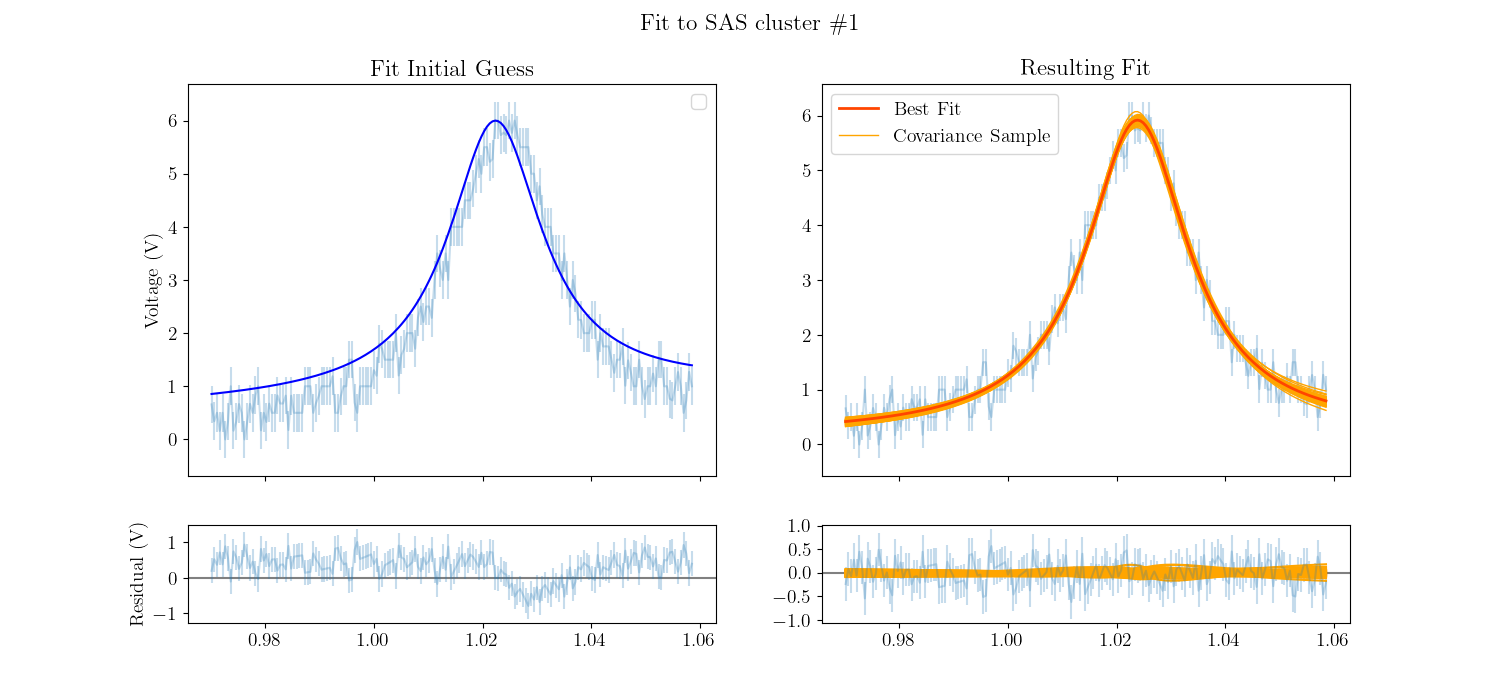

In [13]:
fit_spike(-.02, -.01860, 0)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [1.0881950204189152, 0.009993422413837272, 3.8981292117373174, -7.038538489022029, 7.11829487334237]
fit params:
[ 1.08958161  0.0111616   4.164414    1.11190472 -0.89581706]
cov:
[[ 4.82636337e-08 -1.39365598e-08 -2.43187738e-06  1.80296186e-04
  -1.62554025e-04]
 [-1.39365598e-08  2.64282834e-07  8.02966178e-06 -2.76063677e-04
   2.21811349e-04]
 [-2.43187738e-06  8.02966178e-06  7.98827400e-03 -4.64710243e-02
   3.87347122e-02]
 [ 1.80296186e-04 -2.76063677e-04 -4.64710243e-02  2.78867872e+00
  -2.50288369e+00]
 [-1.62554025e-04  2.21811349e-04  3.87347122e-02 -2.50288369e+00
   2.25068734e+00]]
this_spike = {'center_freq': 1.0895816131367801, 'e_center_freq': 0.00021968985800145362, 'amplitude': 4.164414000957573, 'cluster_id': 0}
len(spike_data) = 6


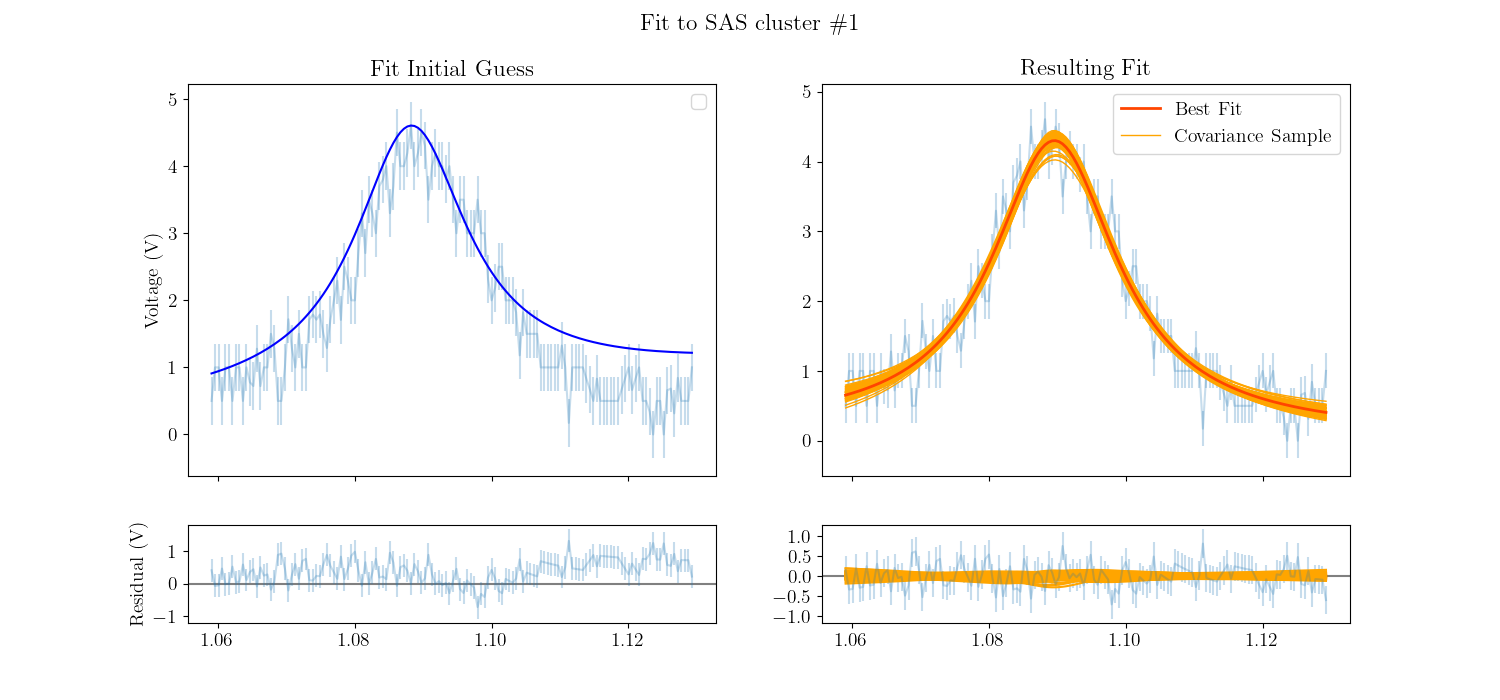

In [14]:
fit_spike(-.01860, -.01750, 0)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [2.3454477644625635, 0.02507080999838096, 6.6757660965393955, 1.646488046252428, -0.5637533961856556]
fit params:
[ 2.34622826  0.03778669  5.8594546   3.49002941 -1.4565955 ]
cov:
[[ 8.59380460e-08  3.92313815e-09  1.11759260e-07  7.87560335e-06
  -3.45494777e-06]
 [ 3.92313815e-09  2.70984730e-07 -1.11716874e-05  6.36782734e-06
  -4.99668667e-06]
 [ 1.11759260e-07 -1.11716874e-05  2.03609039e-03  2.53125933e-04
  -1.48102233e-04]
 [ 7.87560335e-06  6.36782734e-06  2.53125933e-04  2.25054941e-02
  -9.77892682e-03]
 [-3.45494777e-06 -4.99668667e-06 -1.48102233e-04 -9.77892682e-03
   4.29814805e-03]]
this_spike = {'center_freq': 2.3462282619649644, 'e_center_freq': 0.00029315191628218344, 'amplitude': 5.859454596869354, 'cluster_id': 1}
len(spike_data) = 7


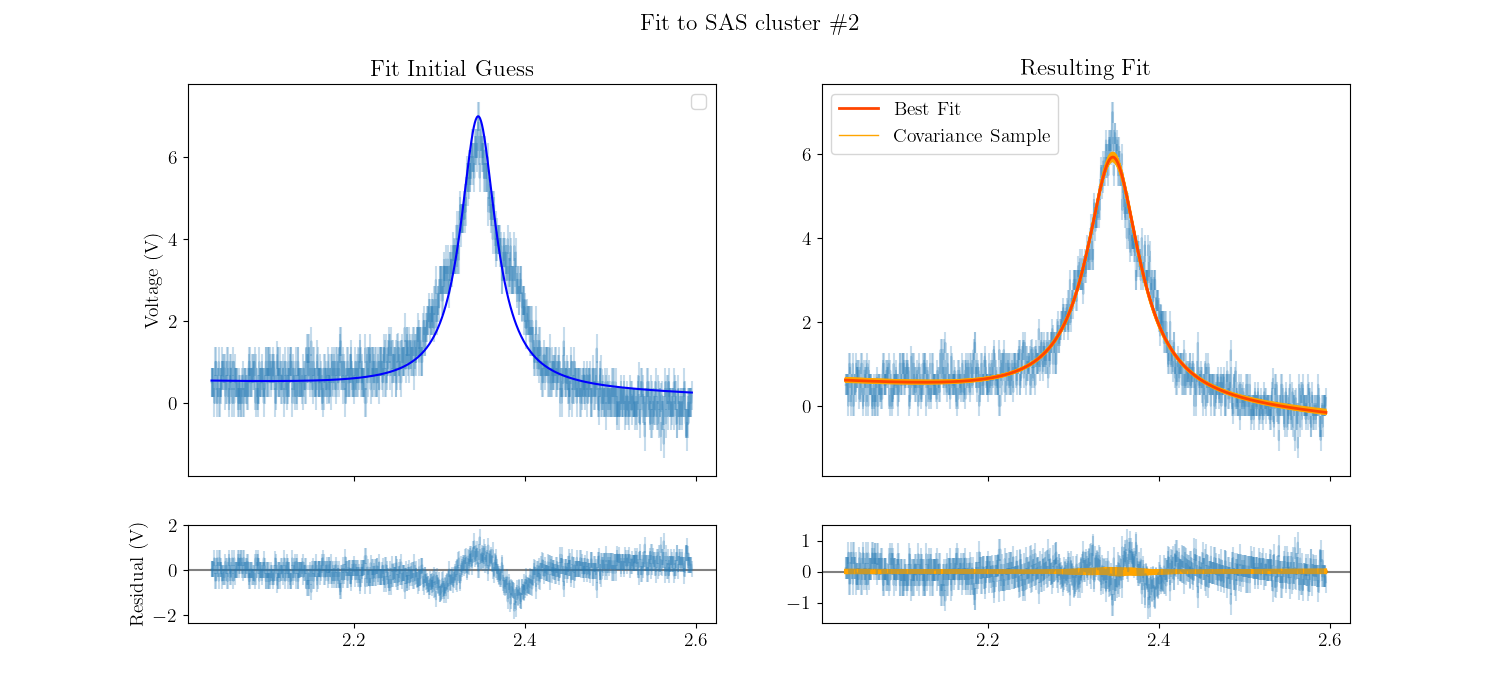

In [15]:
fit_spike(-.004, .004, 1)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [5.901105546006492, 0.01044765766373068, 3.649671943860756, -69.69910947529797, 11.94422994746382]
fit params:
[ 5.90162503e+00  1.13771420e-02  3.30249042e+00 -1.63981775e+01
  2.89848493e+00]
cov:
[[ 1.04413092e-07  3.55756002e-09  2.87462612e-07  4.35841731e-04
  -7.39315792e-05]
 [ 3.55756002e-09  3.96920011e-07 -1.82253601e-05  1.72877756e-04
  -3.30432422e-05]
 [ 2.87462612e-07 -1.82253601e-05  8.61023382e-03  1.47384426e-02
  -2.68542085e-03]
 [ 4.35841731e-04  1.72877756e-04  1.47384426e-02  2.17521208e+01
  -3.68980858e+00]
 [-7.39315792e-05 -3.30432422e-05 -2.68542085e-03 -3.68980858e+00
   6.25971072e-01]]
this_spike = {'center_freq': 5.901625032640311, 'e_center_freq': 0.00032313014701499754, 'amplitude': 3.302490421284275, 'cluster_id': 3}
len(spike_data) = 8


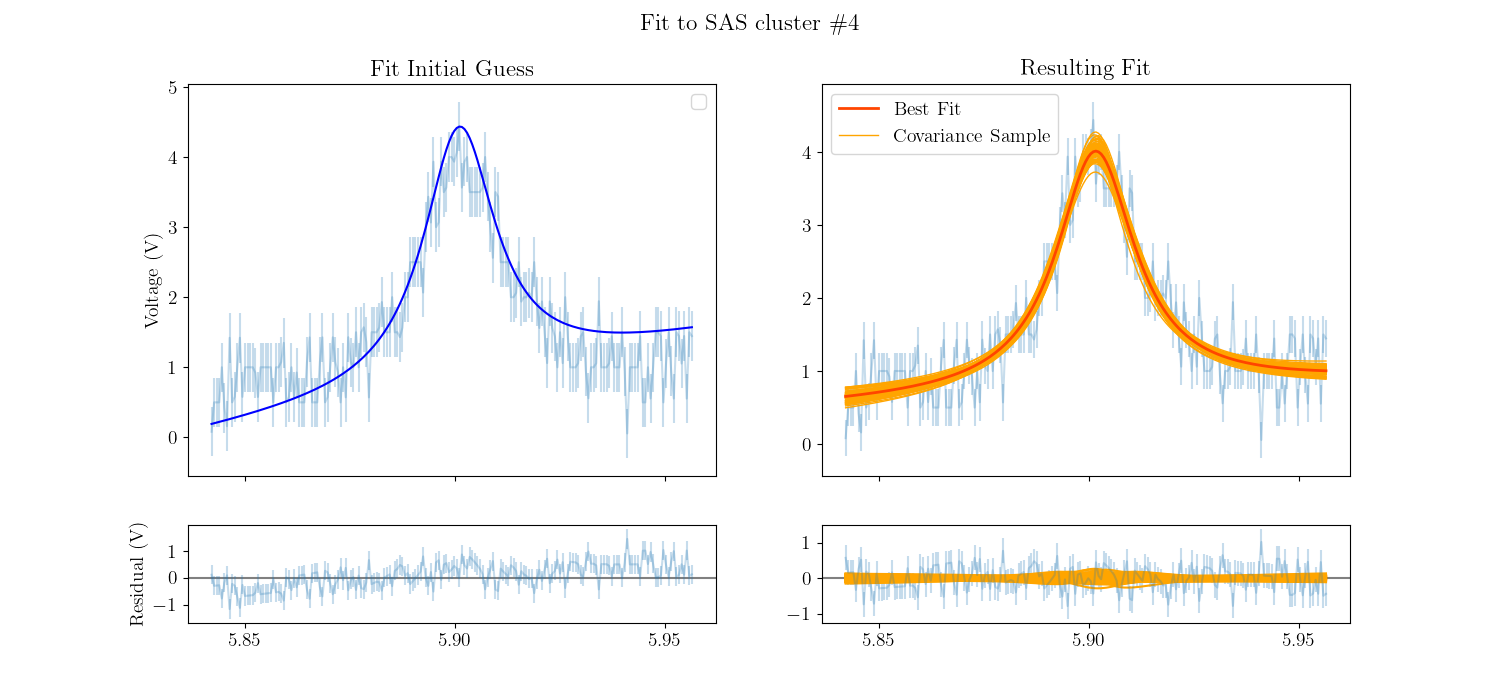

In [16]:
fit_spike(.0477, .0492, 3)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [6.021719510893478, 0.01632943256479491, 9.238932740761465, -95.94646793193705, 16.316329297887]
fit params:
[ 6.02036533e+00  1.40851587e-02  1.05268382e+01 -3.92864408e+01
  6.69632507e+00]
cov:
[[ 1.43979868e-08  5.37205865e-09  1.45334967e-06  2.54634862e-04
  -4.26469109e-05]
 [ 5.37205865e-09  6.95511881e-08 -6.77588096e-07  7.04250219e-04
  -1.19450654e-04]
 [ 1.45334967e-06 -6.77588096e-07  8.87814520e-03  1.94166433e-01
  -3.27718415e-02]
 [ 2.54634862e-04  7.04250219e-04  1.94166433e-01  3.12362652e+01
  -5.23498047e+00]
 [-4.26469109e-05 -1.19450654e-04 -3.27718415e-02 -5.23498047e+00
   8.77419601e-01]]
this_spike = {'center_freq': 6.020365327056871, 'e_center_freq': 0.000119991611577227, 'amplitude': 10.526838222234513, 'cluster_id': 3}
len(spike_data) = 9


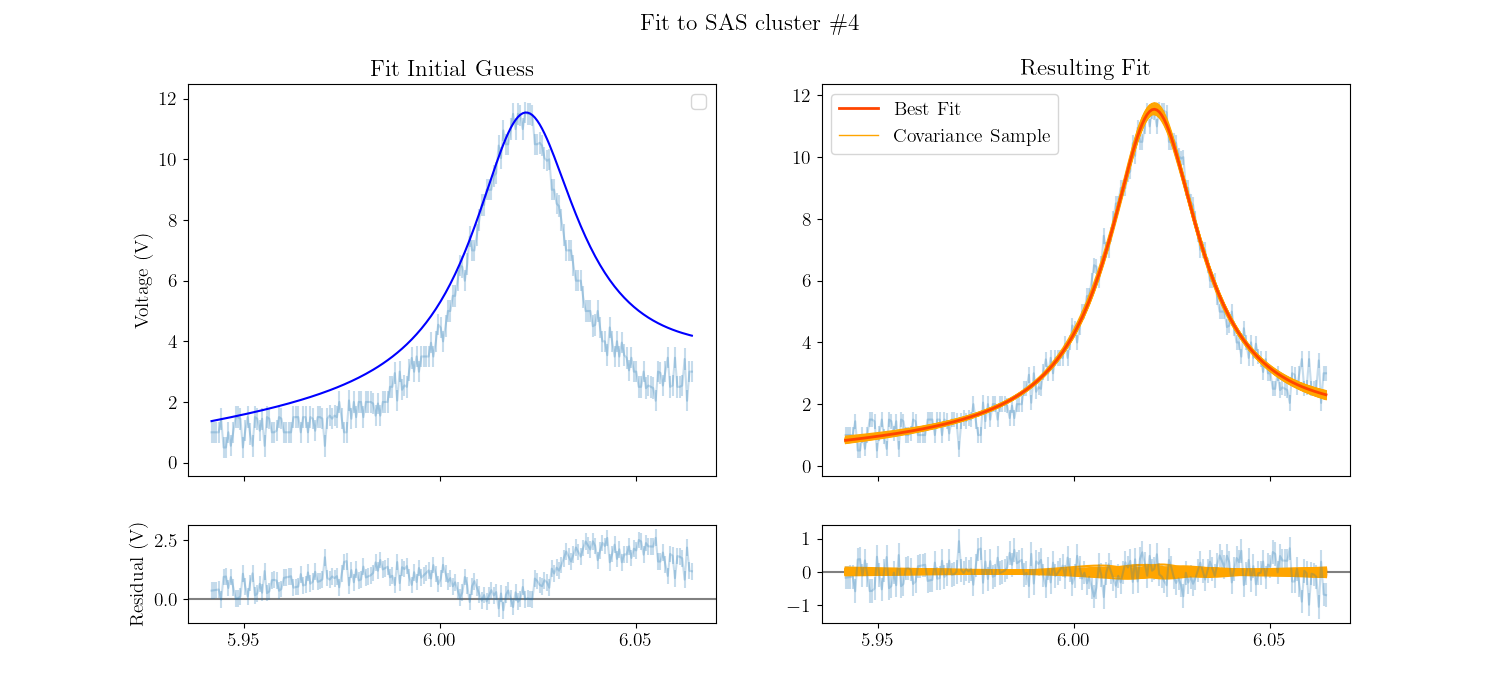

In [17]:
fit_spike(.04900, .0506, 3)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [6.090792825389344, 0.012961653522375993, 6.417462909203239, 78.89978164763848, -12.529936043582842]
fit params:
[ 6.09037848e+00  1.20599182e-02  7.69256966e+00  8.17105474e+01
 -1.32181663e+01]
cov:
[[ 2.63340227e-08 -8.12206376e-09 -2.40872644e-06  8.49935994e-04
  -1.39036035e-04]
 [-8.12206376e-09  1.43740799e-07  7.31942488e-06 -1.26980498e-03
   2.03259351e-04]
 [-2.40872644e-06  7.31942488e-06  1.27401539e-02 -3.75203579e-01
   6.04951811e-02]
 [ 8.49935994e-04 -1.26980498e-03 -3.75203579e-01  1.14004127e+02
  -1.86379622e+01]
 [-1.39036035e-04  2.03259351e-04  6.04951811e-02 -1.86379622e+01
   3.04724640e+00]]
this_spike = {'center_freq': 6.090378480660982, 'e_center_freq': 0.0001622776098860352, 'amplitude': 7.692569655456277, 'cluster_id': 3}
len(spike_data) = 10


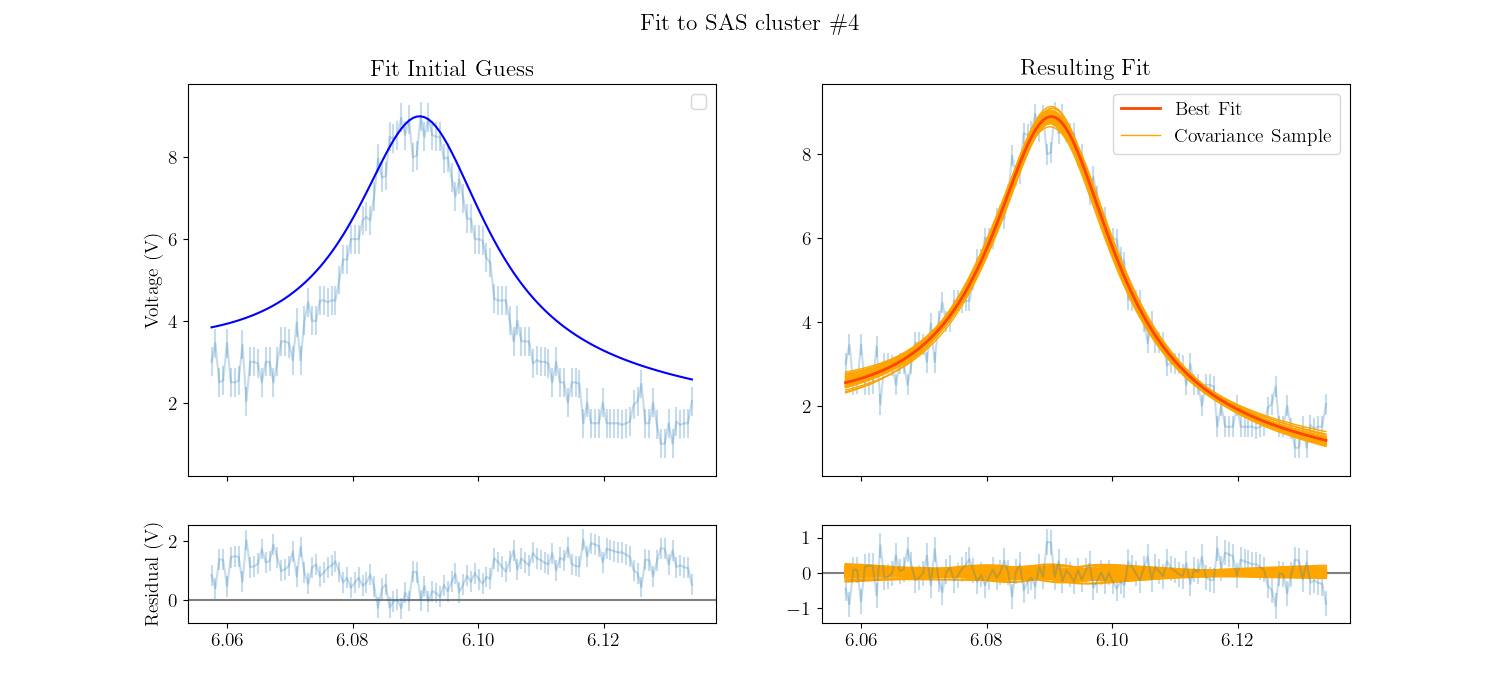

In [18]:
fit_spike(.0505, .0515, 3)

In [19]:
df = pd.DataFrame(spike_data).sort_values('center_freq').reset_index(drop=True)
df

,center_freq,e_center_freq,amplitude,cluster_id
0,0.908612,0.000457,1.672481,0
1,1.023824,0.000131,5.705555,0
2,1.089582,0.000220,4.164414,0
3,2.346228,0.000293,5.859455,1
4,4.906609,0.000405,2.933498,2
5,4.960961,0.000162,11.010315,2
6,4.988604,0.000169,13.645420,2
7,5.901625,0.000323,3.302490,3
8,6.020365,0.000120,10.526838,3
9,6.090378,0.000162,7.692570,3


In [20]:
df.to_csv('sas_spike_data.csv', index=False)